In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn nltk wordcloud


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving spotify_reviews.csv to spotify_reviews.csv


In [ ]:
import pandas as pd
df = pd.read_csv('spotify_reviews.csv')
df.head()


,Review,Rating
0,I love Spotify! The playlists are awesome.,5
1,Too many ads and glitches.,2
2,Good app but crashes sometimes.,3
3,Best music experience ever!,5
4,Not worth paying for premium version.,1


In [ ]:
# Install necessary libraries
!pip install pandas numpy matplotlib seaborn nltk wordcloud textblob


In [ ]:
df.info()
df.isnull().sum()
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  15 non-null     object
 1   Rating  15 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes
(15, 2)


/tmp/ipython-input-1796543453.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='mako')


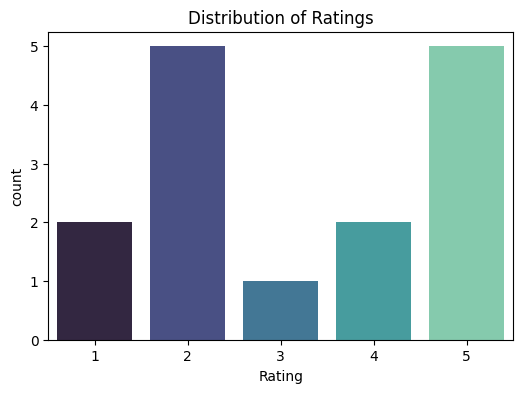

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=df, palette='mako')
plt.title('Distribution of Ratings')
plt.show()


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop = set(stopwords.words('english'))
lemma = WordNetLemmatizer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [lemma.lemmatize(word) for word in words if word not in stop]
    return ' '.join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df[['Review', 'Cleaned_Review']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Review,Cleaned_Review
0,I love Spotify! The playlists are awesome.,love spotify playlist awesome
1,Too many ads and glitches.,many ad glitch
2,Good app but crashes sometimes.,good app crash sometimes
3,Best music experience ever!,best music experience ever
4,Not worth paying for premium version.,worth paying premium version


In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return 'Positive'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Cleaned_Review'].apply(get_sentiment)
df[['Cleaned_Review', 'Sentiment']].head()


,Cleaned_Review,Sentiment
0,love spotify playlist awesome,Positive
1,many ad glitch,Positive
2,good app crash sometimes,Positive
3,best music experience ever,Positive
4,worth paying premium version,Positive


/tmp/ipython-input-3852202867.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='coolwarm')


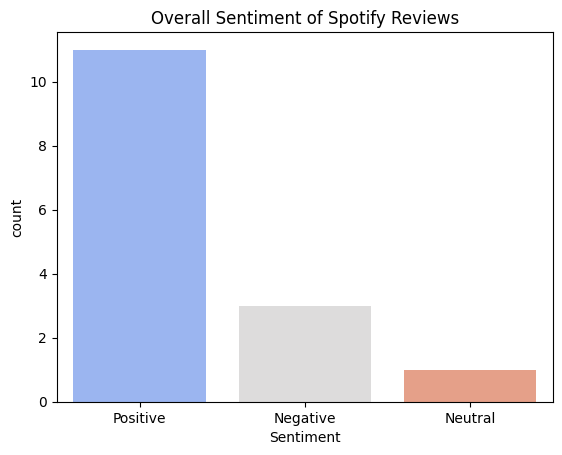

In [ ]:
sns.countplot(x='Sentiment', data=df, palette='coolwarm')
plt.title('Overall Sentiment of Spotify Reviews')
plt.show()


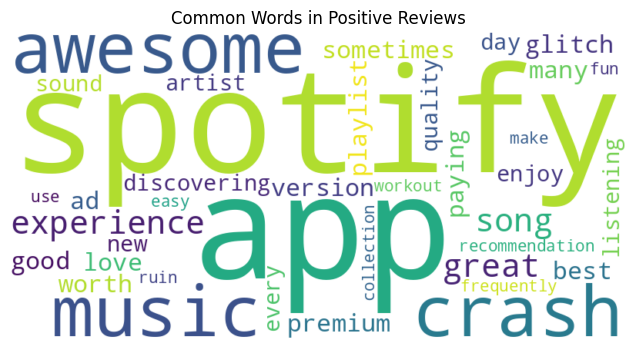

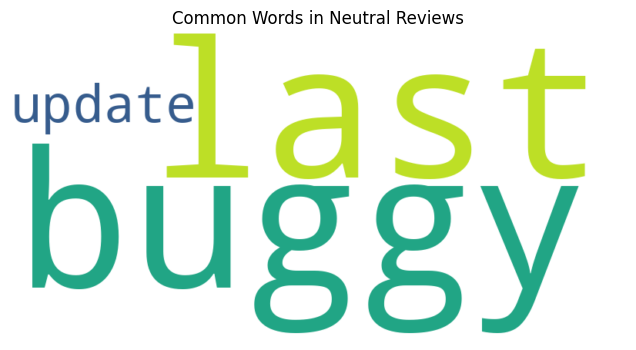

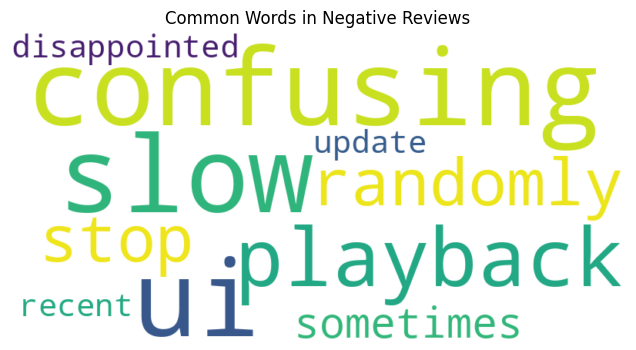

In [ ]:
from wordcloud import WordCloud

for sentiment in ['Positive', 'Neutral', 'Negative']:
    text = ' '.join(df[df['Sentiment']==sentiment]['Cleaned_Review'])
    if text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(8,4))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Common Words in {sentiment} Reviews")
        plt.show()


In [ ]:
df.to_csv('Spotify_Sentiment_Results.csv', index=False)

from google.colab import files
files.download('Spotify_Sentiment_Results.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>